# UpSetHeatmap — Feature Guide

**UpSetHeatmap** extends the functionality of the [UpSetPlot](https://github.com/jnothman/UpSetPlot) package by allowing users to visualise intersection over multiple groups on the same plot through a heatmap.  

This notebook walks you through every major feature.

---

## Contents

1. [Setup & Imports](#1-setup)
2. [Understanding the Data Format](#2-data-format)
3. [Your First UpSet Plot](#3-first-plot)
4. [Reading the Plot — Anatomy of an UpSet diagram](#4-anatomy)
5. [Orientation — Horizontal vs Vertical](#5-orientation)
6. [Sorting Intersections and Categories](#6-sorting)
7. [Filtering Intersections](#7-filtering)
8. [Showing Counts and Percentages](#8-counts)
9. [The Heatmap — Group Distribution](#9-heatmap)
10. [Heatmap Normalisation](#10-normalisation)
11. [Heatmap Colour Palettes](#11-colormaps)
12. [Group Ordering](#12-group-order)
13. [Highlighting Intersections with `style_subsets`](#13-style-subsets)
14. [Stacked Bars — Per-group Breakdown](#14-stacked-bars)
15. [Including Empty Subsets](#15-empty-subsets)
16. [Styling the Plot — Themes and Colours](#16-themes)
17. [Putting It All Together — A Publication-ready Figure](#17-publication)

---
## 1 · Setup & Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib


# Import the UpSet plotting library and the function to generate sample data for this tutorial.
from upsetheatmap import UpSetHeatmap, generate_samples

print("Ready to start!")

Ready to start!


---
## 2. Understanding the Data Format

UpSetHeatmap expects a **pandas DataFrame** very similar to that used by UpSetPlot, with the addition of a `group` column containing the name of the group that each sample belongs to. 


The pandas.DataFrame structure is as follows:

| Requirement | Description |
|-------------|-------------|
| **MultiIndex** | Each index level is a **boolean** (`True`/`False`) flag indicating membership in a category |
| **`group` column** | A string label identifying which group each sample belongs to |
| **`value` column** (optional) | A numeric weight per sample, used when `subset_size='sum'` |

You can use `generate_samples()` to create compatible synthetic data, or construct your own DataFrame following this structure.

In [2]:
# generate_samples() creates a DataFrame ready for UpSetHeatmap
data = generate_samples(
    seed=0,          # random seed for reproducibility
    n_samples=1000,  # total number of samples
    n_categories=4,  # number of categories (e.g. cell types, tags, features)
    n_groups=5,      # number of groups (e.g. treatments, cohorts, conditions)
)

print("Shape:", data.shape)
print("\nFirst few rows:")
data.head(8)

Shape: (1000, 3)

First few rows:


index     value   group
cat0  cat1  cat2  cat3                          
False False False True       0  1.933591  group4
True  False False True       1  2.257949  group1
      True  False False      2  2.082654  group1
False False False True       3  1.720153  group3
      True  False False      4  1.939089  group1
True  True  False False      5  1.535824  group0
False False False True       6  1.250644  group3
True  False False False      7  1.647909  group2

In [3]:
# The MultiIndex levels are the categories
print("Index names (categories):", data.index.names)
print("\nUnique groups:", data['group'].unique())
print("\nNumber of samples per group:")
print(data['group'].value_counts().sort_index())

Index names (categories): ['cat0', 'cat1', 'cat2', 'cat3']

Unique groups: ['group4' 'group1' 'group3' 'group0' 'group2']

Number of samples per group:
group
group0    200
group1    230
group2    170
group3    196
group4    204
Name: count, dtype: int64


### Creating a DataFrame manually

In [4]:
# Example: building a compatible DataFrame from scratch
raw = pd.DataFrame({
    "gene_A": [True,  True,  False, True,  False, True],
    "gene_B": [True,  False, True,  True,  True,  False],
    "gene_C": [False, False, True,  True,  False, False],
    "value":  [1.2,   0.8,   2.1,   1.5,   0.9,   1.1],
    "group":  ["treated", "treated", "control", "control", "treated", "control"],
})
raw = raw.set_index(["gene_A", "gene_B", "gene_C"])
raw

value    group
gene_A gene_B gene_C                
True   True   False     1.2  treated
       False  False     0.8  treated
False  True   True      2.1  control
True   True   True      1.5  control
False  True   False     0.9  treated
True   False  False     1.1  control

---
## 3 · Your First UpSet Plot <a id='3-first-plot'></a>

The simplest call you need: create an `UpSet` object and call `.plot()` on a matplotlib `Figure`.

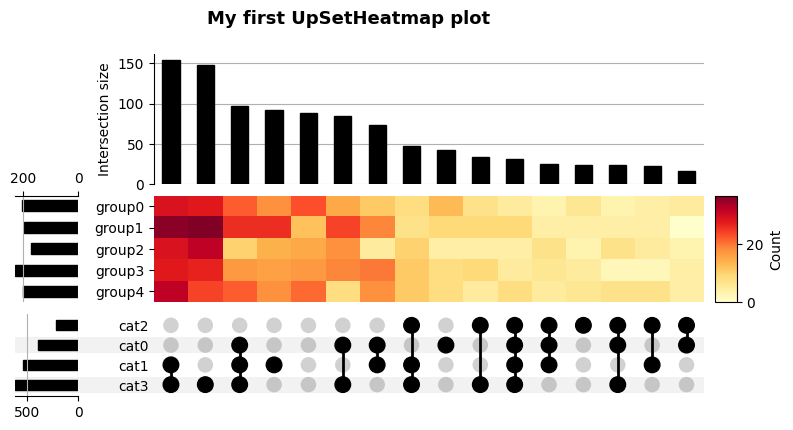

In [5]:
fig = plt.figure(figsize=(13, 6))

upset = UpSetHeatmap(data, subset_size="count", sort_by="cardinality")
upset.plot(fig)

fig.suptitle("My first UpSetHeatmap plot", fontsize=13, fontweight="bold")
plt.show()

**Key parameters of `UpSetHeatmap()`:**

| Parameter | Default | What it does |
|-----------|---------|---------------|
| `subset_size` | `'auto'` | How to measure intersection size: `'count'` (number of rows) or `'sum'` (sum of `value` column) |
| `sort_by` | `'degree'` | How to order the bars: `'cardinality'` (largest first), `'degree'` (fewest categories first), `'input'` |
| `sort_categories_by` | `'cardinality'` | How to order the category rows: `'cardinality'` (most common first) or `'input'` |

---
## 4. Changing the orientation of the plot

You can define the plot's orientation using the `orientation='vertical'` parameter.

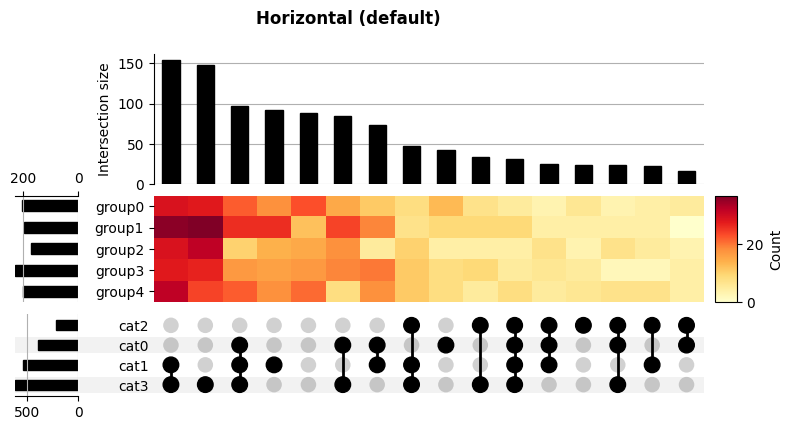

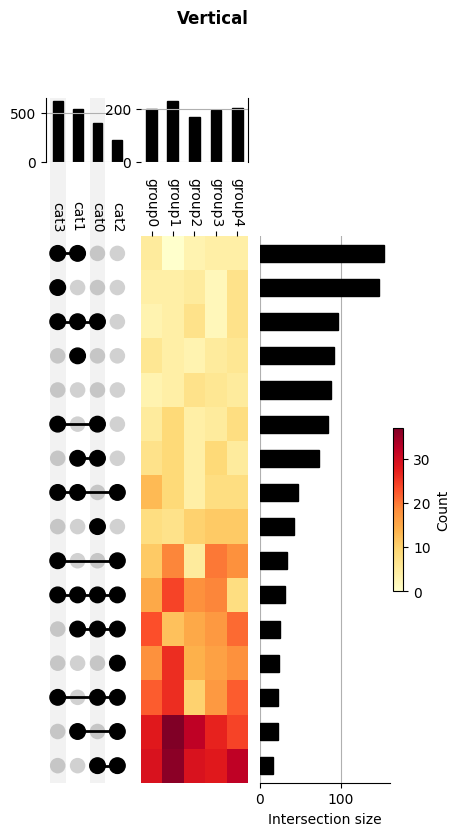

In [6]:
fig, (ax_label_h, ax_label_v) = plt.subplots(1, 2, figsize=(1, 1))  # dummy, just for labels
plt.close(fig)

# --- Horizontal (default) ---
fig_h = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality").plot(fig_h)
fig_h.suptitle("Horizontal (default)", fontsize=12, fontweight="bold")
plt.show()

# --- Vertical ---
fig_v = plt.figure(figsize=(7, 12))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality", orientation="vertical").plot(fig_v)
fig_v.suptitle("Vertical", fontsize=12, fontweight="bold")
plt.show()

---
## 5. Sorting Intersections and Categories

Similar to the *UpSet* you can use `sort_by` to order the intersection bars along the x axis.

| Value | Result |
|-------|--------|
| `'cardinality'` | Largest intersection first |
| `'-cardinality'` | Smallest intersection first |
| `'degree'` | Fewest active categories first (default) |
| `'-degree'` | Most active categories first |
| `'input'` | Preserve original data order |

Ordering insterections by "degree" - simpler intersections first, more complex intersections later.


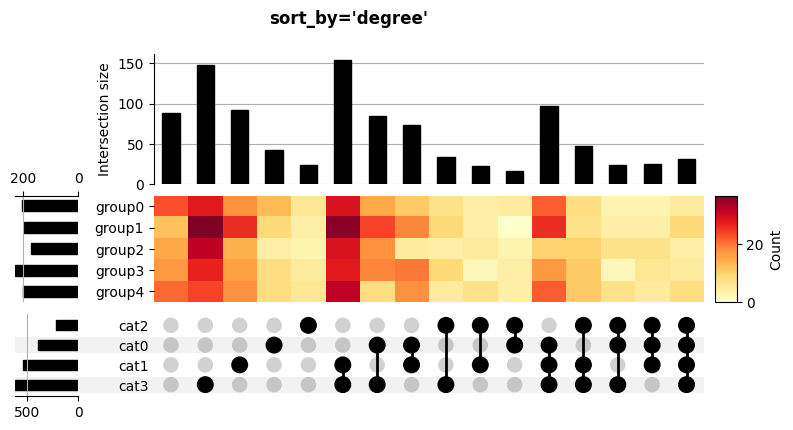

Ordering insterections by "cardinality" - the most abundant intersections appear first.


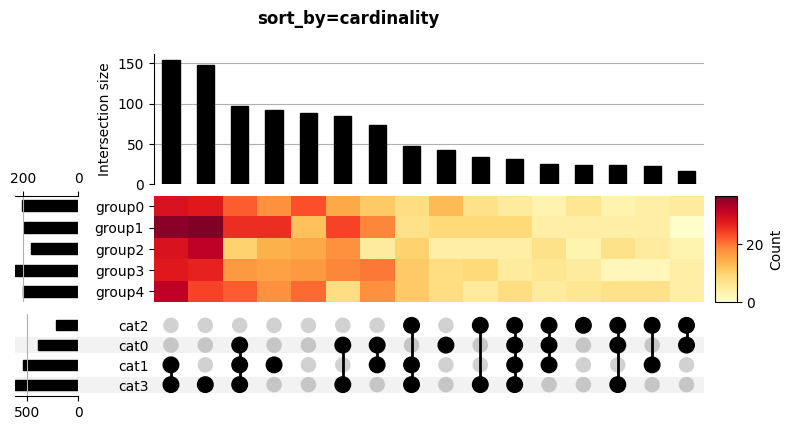

Ordering insterections by "input" - preserving the original order of the data.


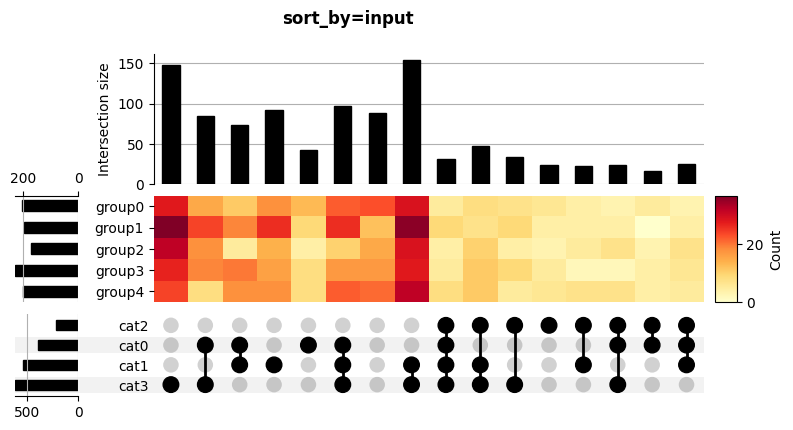

In [9]:
print('Ordering insterections by \033[1m"degree"\033[0m - simpler intersections first, more complex intersections later.')
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="degree").plot(fig)
fig.suptitle(f"sort_by='degree'", fontsize=12, fontweight="bold")
plt.show()

print('Ordering insterections by \033[1m"cardinality"\033[0m - the most abundant intersections appear first.')
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality").plot(fig)
fig.suptitle(f"sort_by=cardinality", fontsize=12, fontweight="bold")
plt.show()

print('Ordering insterections by \033[1m"input"\033[0m - preserving the original order of the data.')
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="input").plot(fig)
fig.suptitle(f"sort_by=input", fontsize=12, fontweight="bold")
plt.show()


---
## 6. Filtering Intersections <a id='7-filtering'></a>

There are three ways to filter the intersections that are displayed.

### Filter by degree (number of active categories)

intersections


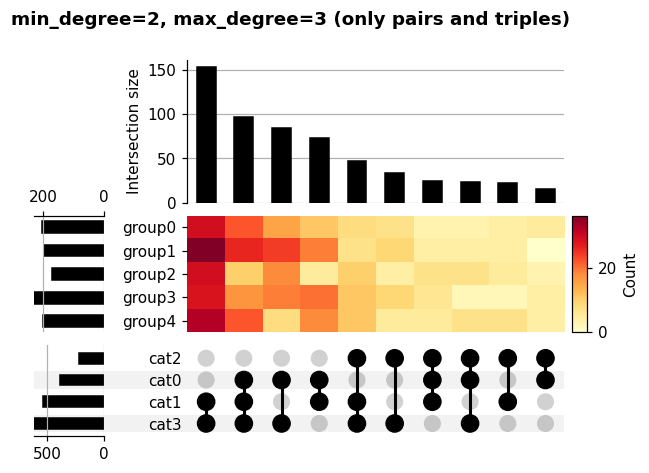

In [ ]:
# Only show intersections where exactly 2 or 3 categories are active
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      min_degree=2, max_degree=3).plot(fig)
fig.suptitle("min_degree=2, max_degree=3 (only pairs and triples)",
             fontsize=12, fontweight="bold")
plt.show()

### Filter by intersection size

intersections


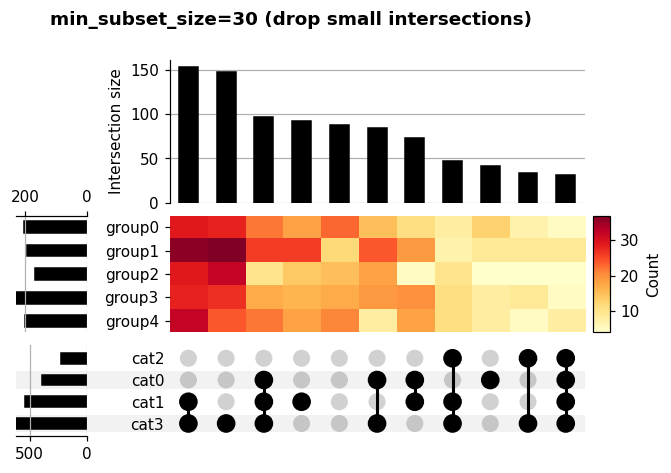

In [ ]:
# Only show intersections with at least 30 samples
# It can also be expressed as a percentage of the total (i.e. 5%)
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      min_subset_size=30).plot(fig)
fig.suptitle("min_subset_size=30 (drop small intersections)",
             fontsize=12, fontweight="bold")
plt.show()

### Keep only the top-N intersections by size

intersections


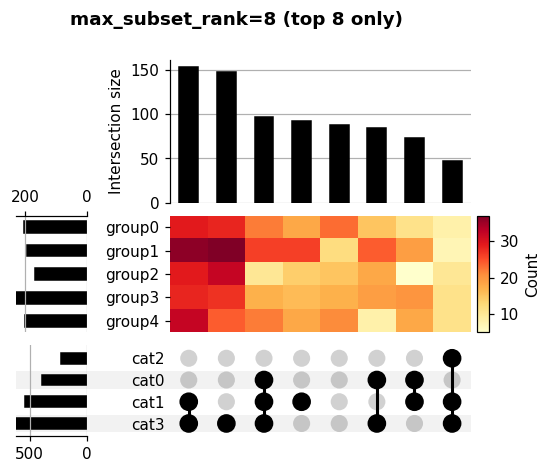

In [ ]:
# Show only the 8 largest intersections
fig = plt.figure(figsize=(11, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      max_subset_rank=8).plot(fig)
fig.suptitle("max_subset_rank=8 (top 8 only)", fontsize=12, fontweight="bold")
plt.show()

---
## 8. Showing Counts and Percentages <a id='8-counts'></a>

`show_counts` and `show_percentages` add labels on top of bars and next to category totals.

intersections


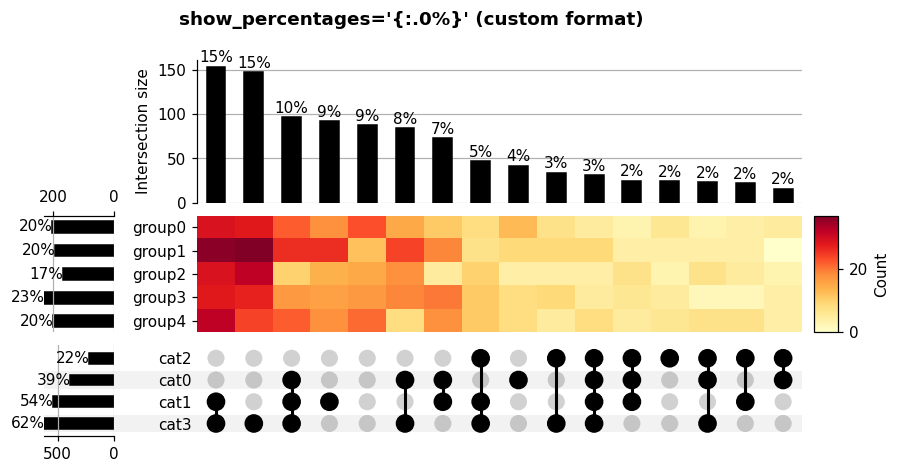

In [ ]:
# You can supply a custom format string for either.
# Format strings use Python's str.format() syntax: {:d} = integer, {:.1%} = percentage
fig = plt.figure(figsize=(13, 6))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      show_percentages="{:.0%}").plot(fig)   # percentages only, no decimal
fig.suptitle("show_percentages='{:.0%}' (custom format)",
             fontsize=12, fontweight="bold")
plt.show()

---
## 9 · The Heatmap — Group Distribution <a id='9-heatmap'></a>

The heatmap is the central new feature of UpSetHeatmap. For every intersection (column in horizontal mode), it shows how the samples in that intersection are distributed across your groups.

- Each **cell** represents one (intersection, group) combination
- The colour encodes the **count** (or normalised value — see §10) for that cell
- The **group totals bar chart** (left of heatmap) shows total samples per group

The heatmap is drawn automatically whenever the input data has a `group` column.

intersections


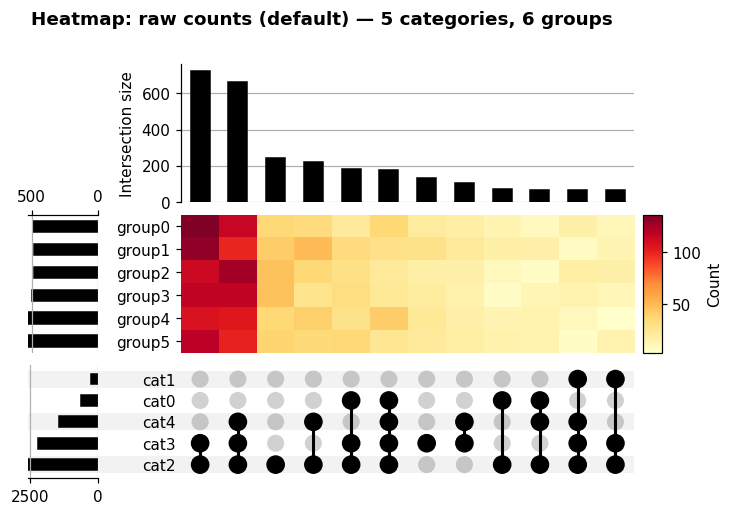

In [ ]:
# Use a larger dataset to make the heatmap patterns more visible
data_large = generate_samples(seed=1, n_samples=3000, n_categories=5, n_groups=6)

fig = plt.figure(figsize=(16, 7))
UpSetHeatmap(data_large, subset_size="count", sort_by="cardinality",
      max_subset_rank=12).plot(fig)
fig.suptitle("Heatmap: raw counts (default) — 5 categories, 6 groups",
             fontsize=12, fontweight="bold")
plt.show()

> **Reading the heatmap:** A bright cell in a column means that group has an unusually high number of samples in that intersection. A pale cell means few samples.
>
> Because total intersection sizes vary enormously (some are hundreds, some are single digits), raw counts make it hard to compare across columns. That is where **normalisation** helps.

---
## 10 · Heatmap Normalisation <a id='10-normalisation'></a>

The `heatmap_normalize` parameter controls what the colour represents.

| Value | What the colour represents |
|-------|----------------------------|
| `None` (default) | Raw count — useful when absolute numbers matter |
| `'fraction'` | Fraction of the intersection belonging to each group — useful when you want to compare the *composition* of intersections |
| `'zscore'` | Z-score across groups for each intersection — highlights which groups are over/under-represented relative to the mean |

intersections


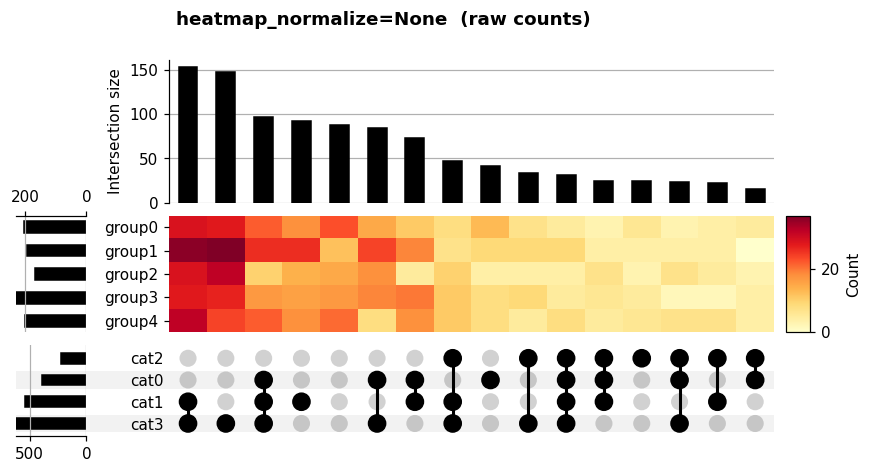

In [ ]:
# --- None: raw counts ---
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      heatmap_normalize=None).plot(fig)
fig.suptitle("heatmap_normalize=None  (raw counts)", fontsize=12, fontweight="bold")
plt.show()

intersections


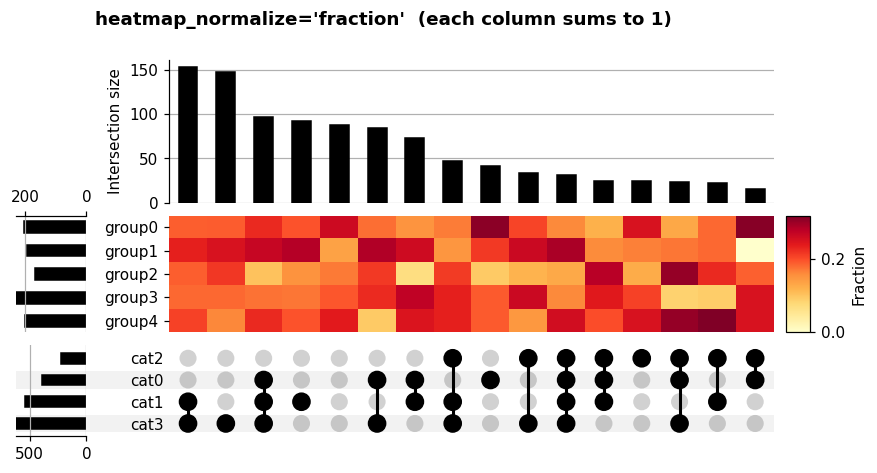

In [ ]:
# --- fraction: each column sums to 1.0 ---
# A dark cell means that group has a large share of this intersection.
# All columns are now on the same 0–1 scale, making them directly comparable.
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      heatmap_normalize="fraction").plot(fig)
fig.suptitle("heatmap_normalize='fraction'  (each column sums to 1)",
             fontsize=12, fontweight="bold")
plt.show()

intersections


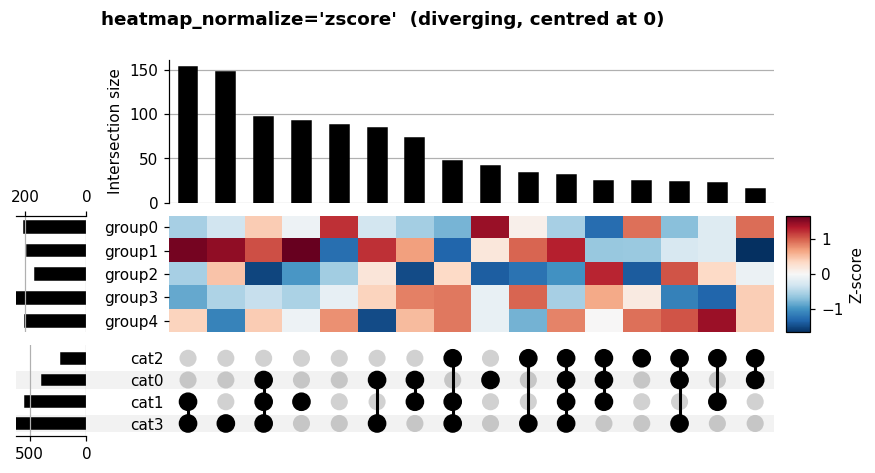

In [ ]:
# --- zscore: diverging colour, centred at 0 ---
# Red = above-average count for this group in this intersection
# Blue = below-average count
# A diverging colormap (e.g. RdBu_r) works best here.
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      heatmap_normalize="zscore",
      heatmap_cmap="RdBu_r").plot(fig)
fig.suptitle("heatmap_normalize='zscore'  (diverging, centred at 0)",
             fontsize=12, fontweight="bold")
plt.show()

---
## 11 · Heatmap Colour Palettes <a id='11-colormaps'></a>

The `heatmap_cmap` parameter accepts any matplotlib colormap name. Some good choices:

| Normalisation | Recommended colormaps |
|--------------|----------------------|
| `None` / `'fraction'` | `'YlOrRd'`, `'YlGnBu'`, `'viridis'`, `'plasma'`, `'Blues'` |
| `'zscore'` | `'RdBu_r'`, `'coolwarm'`, `'PiYG'`, `'bwr'` (diverging) |

intersections


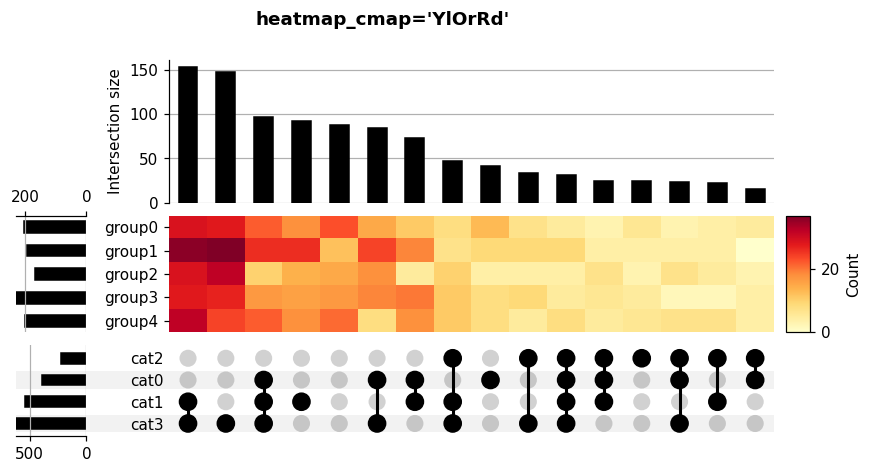

intersections


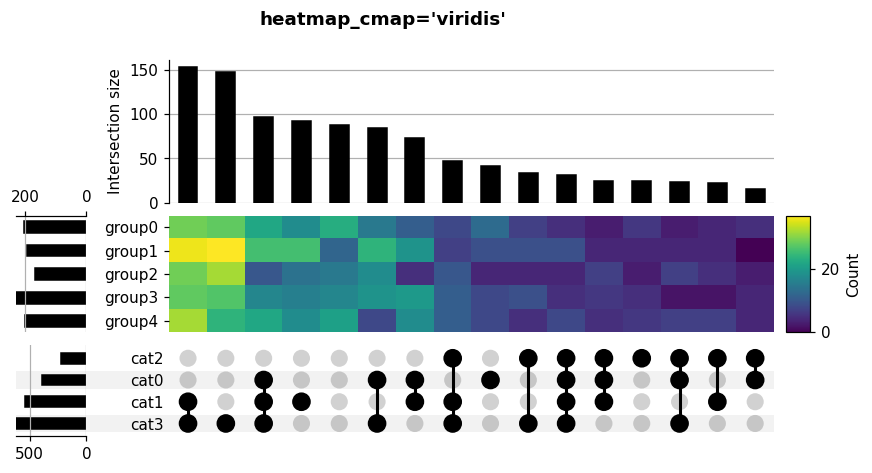

intersections


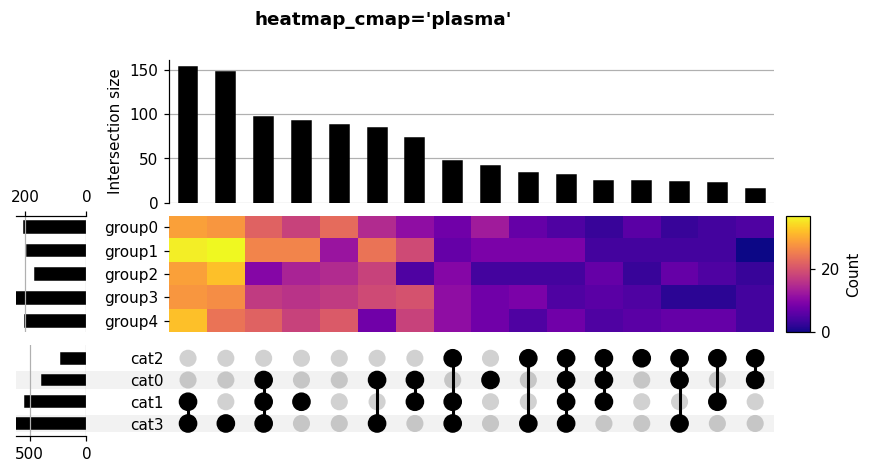

intersections


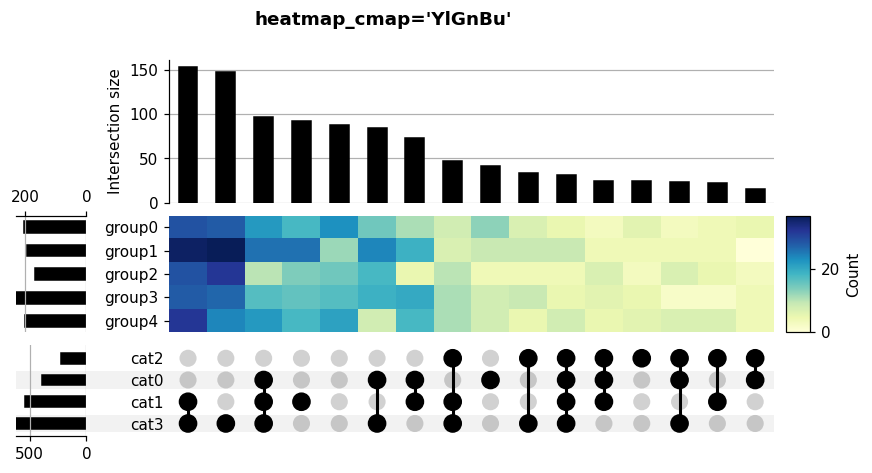

In [ ]:
cmaps = ["YlOrRd", "viridis", "plasma", "YlGnBu"]

for cmap in cmaps:
    fig = plt.figure(figsize=(13, 5))
    UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
          heatmap_cmap=cmap).plot(fig)
    fig.suptitle(f"heatmap_cmap='{cmap}'", fontsize=12, fontweight="bold")
    plt.show()

intersections


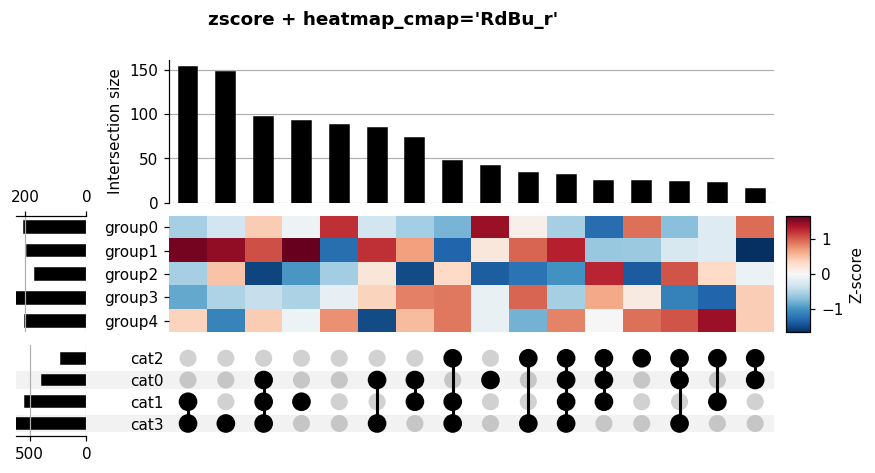

intersections


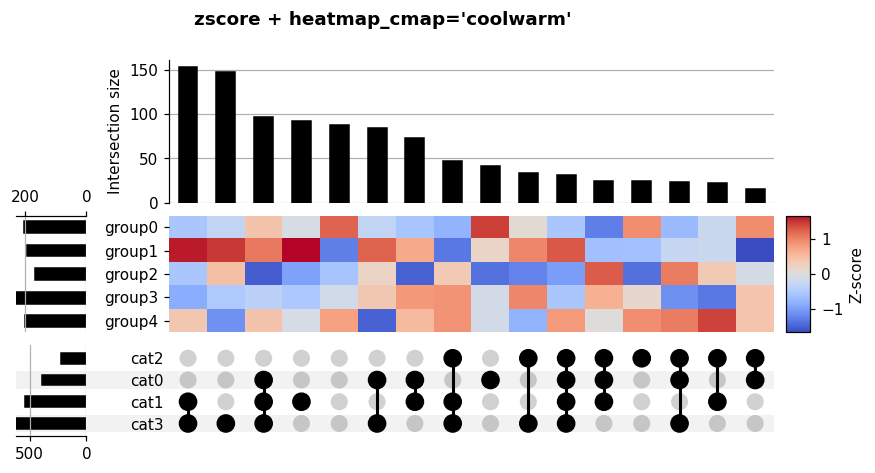

intersections


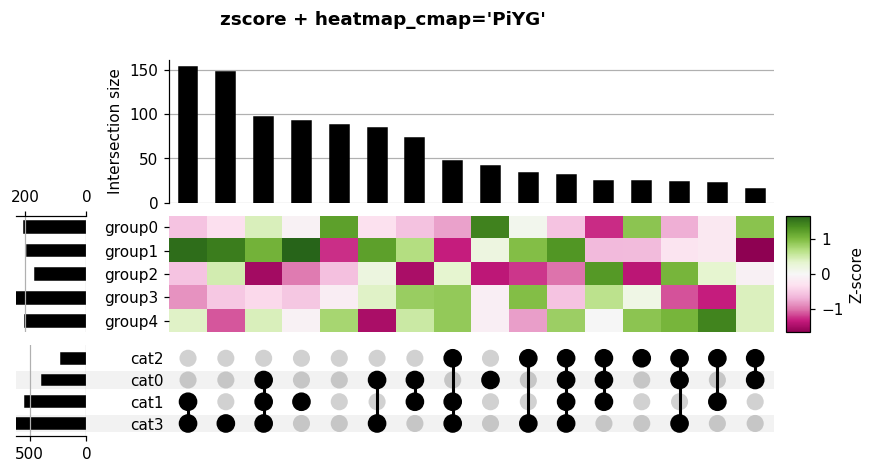

In [ ]:
# Diverging colormaps for z-score normalisation
div_cmaps = ["RdBu_r", "coolwarm", "PiYG"]

for cmap in div_cmaps:
    fig = plt.figure(figsize=(13, 5))
    UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
          heatmap_normalize="zscore", heatmap_cmap=cmap).plot(fig)
    fig.suptitle(f"zscore + heatmap_cmap='{cmap}'", fontsize=12, fontweight="bold")
    plt.show()

---
## 12 · Group Ordering <a id='12-group-order'></a>

By default groups appear in the order they were encountered in the data. You have two ways to change this:

| Parameter | Value | Effect |
|-----------|-------|--------|
| `sort_groups_by` | `'count'` | Sort groups from largest to smallest |
| `sort_groups_by` | `'custom'` | Use the list you provide in `group_order` |
| `group_order` | list of group names | Explicit ordering (implies `sort_groups_by='custom'`) |

intersections


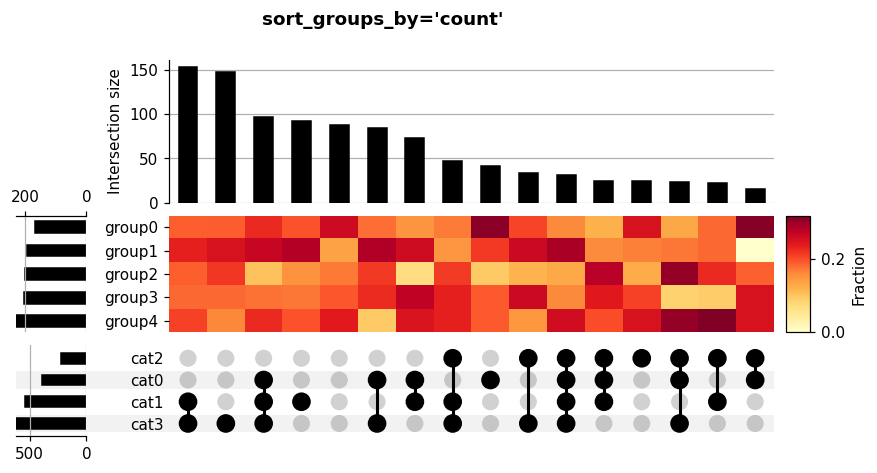

In [ ]:
# Sort groups by their total size (largest at top of heatmap)
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      sort_groups_by="count",
      heatmap_normalize="fraction").plot(fig)
fig.suptitle("sort_groups_by='count'", fontsize=12, fontweight="bold")
plt.show()

intersections


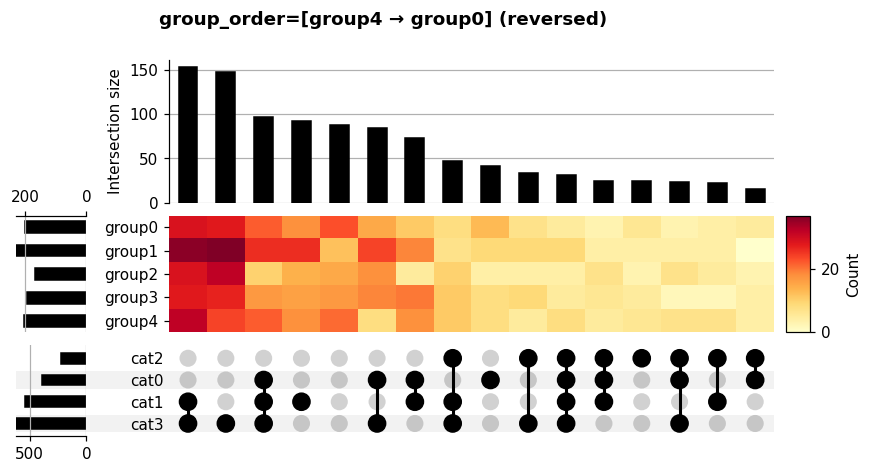

In [ ]:
# Explicit custom ordering — pass the group names in the order you want
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      group_order=["group4", "group3", "group2", "group1", "group0"]).plot(fig)
fig.suptitle("group_order=[group4 → group0] (reversed)",
             fontsize=12, fontweight="bold")
plt.show()

---
## 13 · Highlighting Intersections with `style_subsets` <a id='13-style-subsets'></a>

`upset.style_subsets()` lets you give specific intersections a different colour, edge, or line style in the bar chart and matrix.

You can select intersections using any combination of:

| Argument | Selects intersections that... |
|----------|-------------------------------|
| `present='cat0'` | have **cat0** active |
| `absent='cat1'` | have **cat1** inactive |
| `min_degree=2` | have **at least 2** active categories |
| `max_subset_size=50` | have **at most 50** samples |

intersections


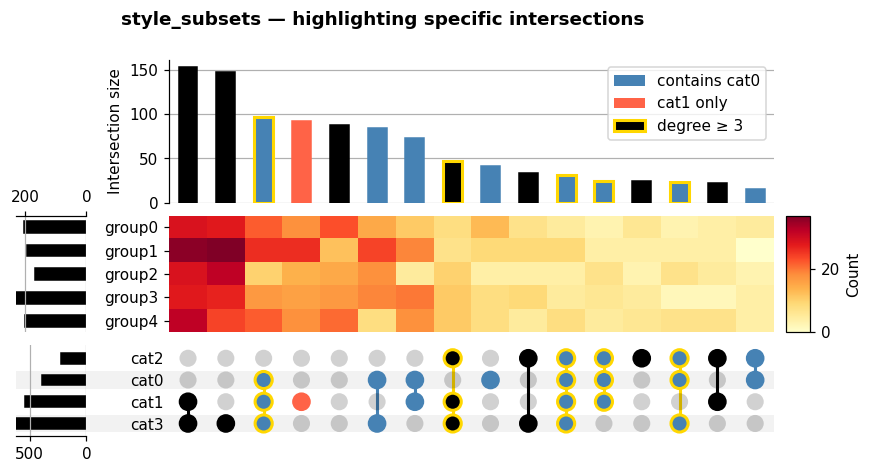

In [ ]:
fig = plt.figure(figsize=(13, 6))

upset = UpSetHeatmap(data, subset_size="count", sort_by="cardinality")

# Colour all intersections that include cat0 in blue
upset.style_subsets(present="cat0",
                    facecolor="steelblue",
                    label="contains cat0")

# Colour the intersection where only cat1 is present in orange
upset.style_subsets(present="cat1", absent=["cat0", "cat2", "cat3"],
                    facecolor="tomato",
                    label="cat1 only")

# Outline all high-degree intersections in gold
upset.style_subsets(min_degree=3,
                    edgecolor="gold", linewidth=2,
                    label="degree ≥ 3")

upset.plot(fig)
fig.suptitle("style_subsets — highlighting specific intersections",
             fontsize=12, fontweight="bold")
plt.show()

> **Note:** When you supply a `label`, it automatically appears in the legend. You can stack multiple `style_subsets()` calls — later calls override earlier ones for the same intersection.

---
## 14 · Stacked Bars — Per-group Breakdown <a id='14-stacked-bars'></a>

`upset.add_stacked_bars()` adds an extra panel above the intersection bars, showing the per-group breakdown of each intersection as a stacked bar. This is an alternative to (or complement of) the heatmap.

| Parameter | Description |
|-----------|-------------|
| `by` | Column to group by — typically `'group'` |
| `colors` | List of colours, one per group |
| `title` | Y-axis label for the stacked bars panel |
| `elements` | Height of the panel in grid units (default 3) |

intersections
extra1


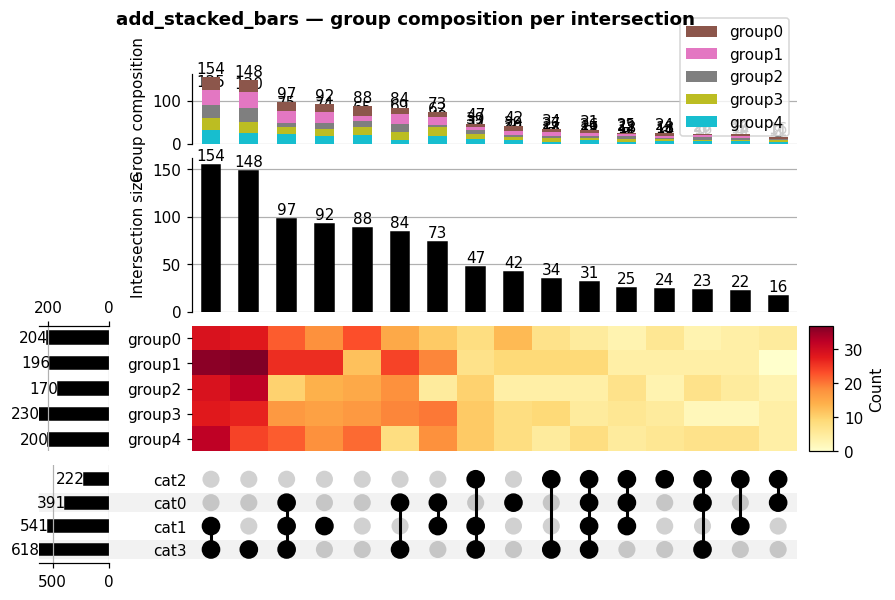

In [ ]:
fig = plt.figure(figsize=(13, 8))

upset = UpSetHeatmap(data, subset_size="count", sort_by="cardinality", show_counts=True)

upset.add_stacked_bars(
    by="group",
    colors=plt.cm.tab10.colors,   # one colour per group
    title="Group composition",
    elements=3,
)

upset.plot(fig)
fig.suptitle("add_stacked_bars — group composition per intersection",
             fontsize=12, fontweight="bold")
plt.show()

You can add **both** stacked bars and the heatmap to get two complementary views:

intersections
extra1


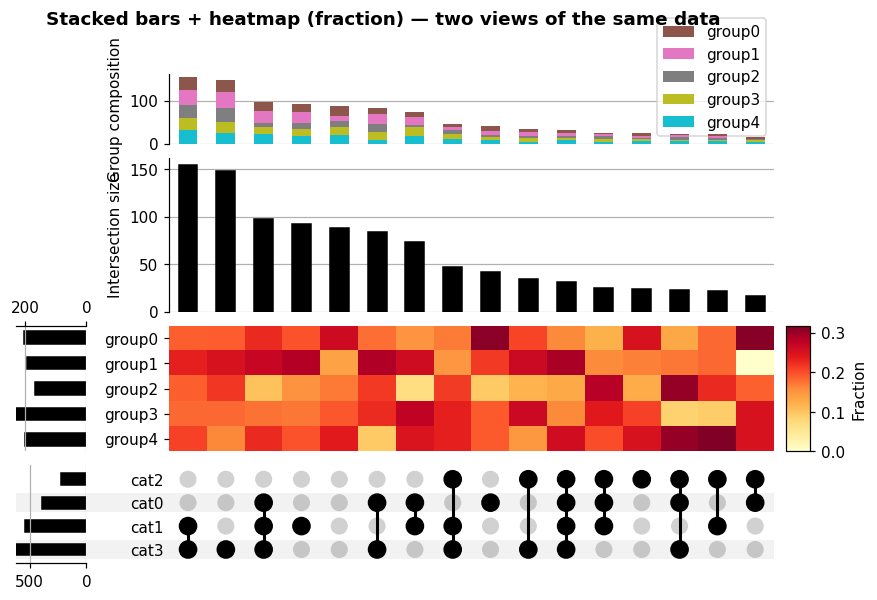

In [ ]:
fig = plt.figure(figsize=(13, 9))

upset = UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
              heatmap_normalize="fraction", heatmap_cmap="YlOrRd")
upset.add_stacked_bars(by="group", colors=plt.cm.tab10.colors,
                       title="Group composition", elements=3)
upset.plot(fig)
fig.suptitle("Stacked bars + heatmap (fraction) — two views of the same data",
             fontsize=12, fontweight="bold")
plt.show()

---
## 15 · Including Empty Subsets <a id='15-empty-subsets'></a>

By default, intersections with no samples are hidden. Setting `include_empty_subsets=True` forces all $2^n$ possible combinations to appear — handy when the *absence* of a subset is meaningful or when you want a symmetric layout.

> Works for up to 10 categories ($2^{10}$ = 1024 bars).

intersections


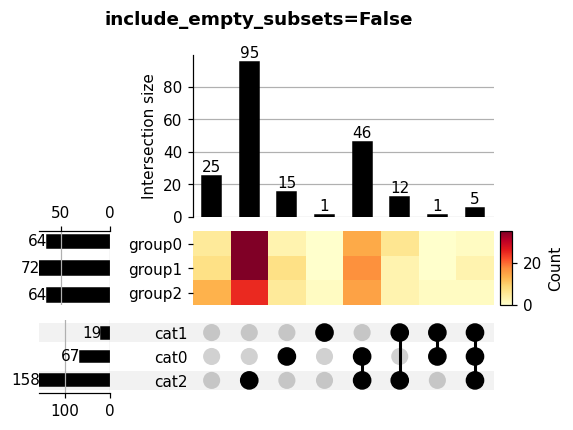

intersections


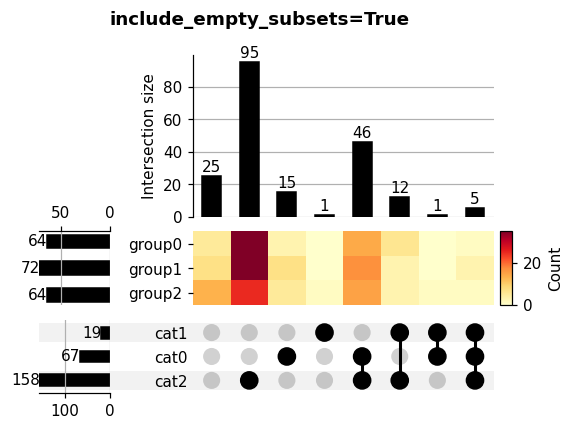

In [ ]:
data_small = generate_samples(seed=42, n_samples=200, n_categories=3, n_groups=3)

fig, _ = plt.subplots(figsize=(1, 1))
plt.close(fig)

for include in [False, True]:
    fig = plt.figure(figsize=(11, 5))
    UpSetHeatmap(data_small, subset_size="count", sort_by="degree",
          include_empty_subsets=include, show_counts=True).plot(fig)
    fig.suptitle(f"include_empty_subsets={include}",
                 fontsize=12, fontweight="bold")
    plt.show()

---
## 16 · Styling the Plot — Themes and Colours <a id='16-themes'></a>

Several `UpSet` parameters control the visual appearance of the bars and matrix:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `facecolor` | `'auto'` | Colour of active dots and bars (auto-detects light/dark background) |
| `other_dots_color` | `0.18` | Colour of inactive dots (float = opacity multiplier) |
| `shading_color` | `0.05` | Colour of alternating row shading (float = opacity) |
| `with_lines` | `True` | Draw connecting lines between matrix dots |

intersections


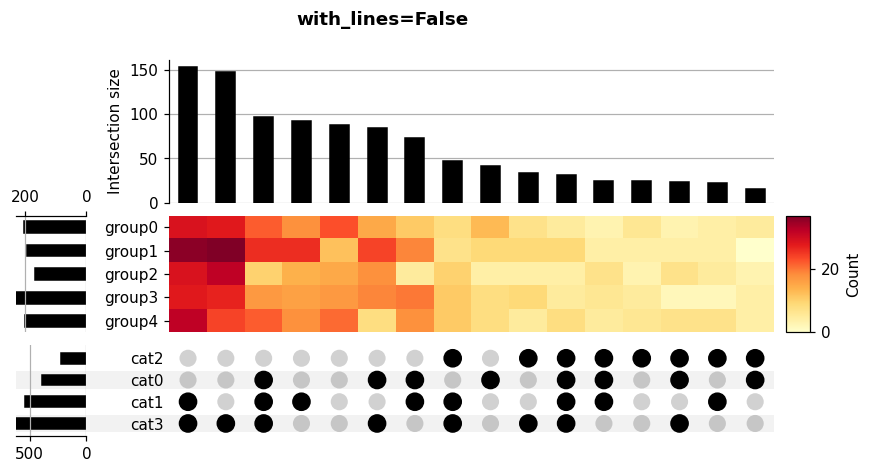

In [ ]:
# Without connecting lines
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      with_lines=False).plot(fig)
fig.suptitle("with_lines=False", fontsize=12, fontweight="bold")
plt.show()

intersections


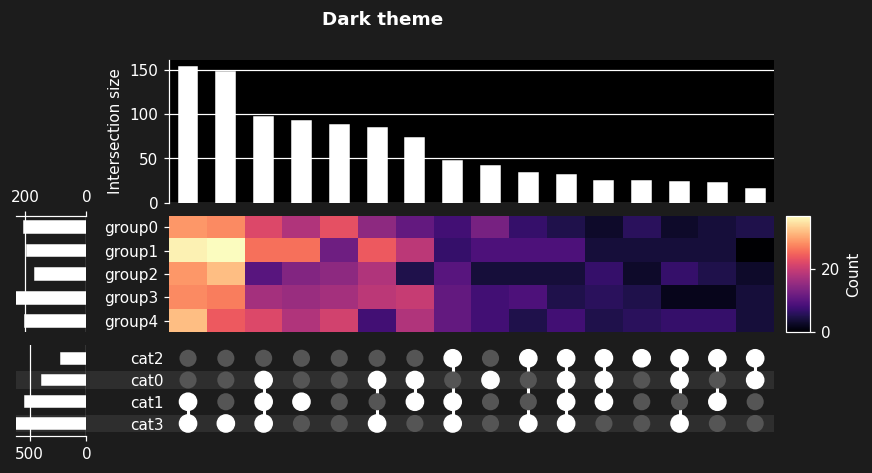

In [ ]:
# Dark background
with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(13, 5), facecolor="#1c1c1c")
    UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
          facecolor="white",
          shading_color="#2e2e2e",
          other_dots_color="#555555",
          heatmap_cmap="magma").plot(fig)
    fig.suptitle("Dark theme", fontsize=12, fontweight="bold", color="white")
    plt.show()

intersections


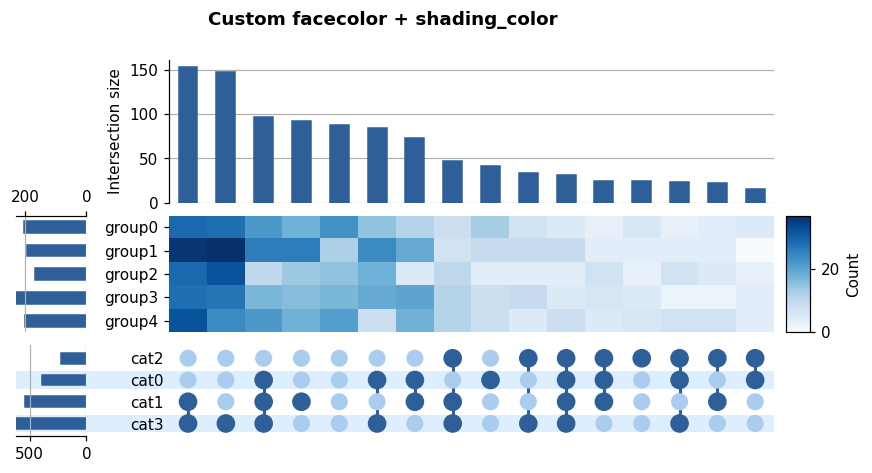

In [ ]:
# Custom facecolor + strong shading
fig = plt.figure(figsize=(13, 5))
UpSetHeatmap(data, subset_size="count", sort_by="cardinality",
      facecolor="#2e5f99",         # navy blue bars and dots
      shading_color="#ddeeff",     # light blue row shading
      other_dots_color="#aaccee",  # pale blue inactive dots
      heatmap_cmap="Blues").plot(fig)
fig.suptitle("Custom facecolor + shading_color", fontsize=12, fontweight="bold")
plt.show()

---
## 17 · Putting It All Together — A Publication-ready Figure <a id='17-publication'></a>

Here is a single plot that combines many features at once: large dataset, filtered to the top intersections, fraction-normalised heatmap, highlighted subsets, counts shown, and a clean layout.

intersections


/var/folders/41/rkq2s7yd6s9b2pywvn781m440000gp/T/ipykernel_38955/3379738370.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


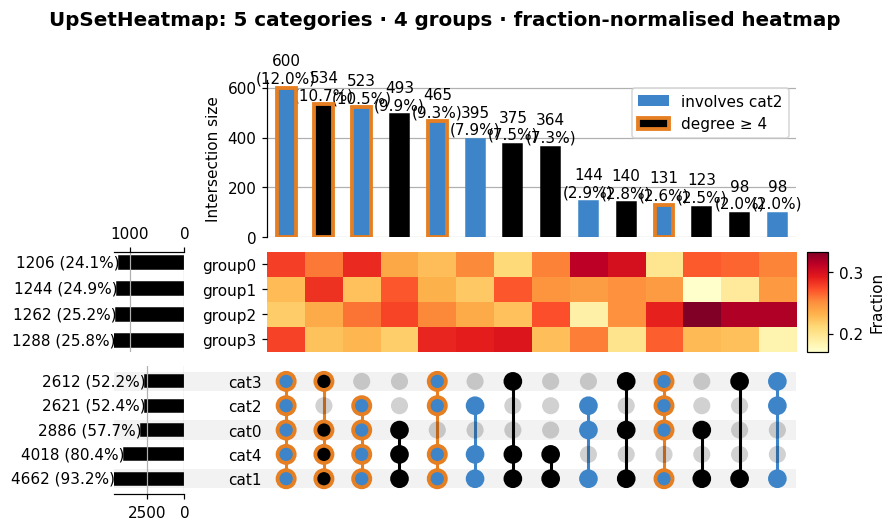

In [ ]:
data_pub = generate_samples(seed=7, n_samples=5000, n_categories=5, n_groups=4)

fig = plt.figure(figsize=(16, 7))

upset = UpSetHeatmap(
    data_pub,
    subset_size="count",
    sort_by="cardinality",
    max_subset_rank=14,          # show only top 14 intersections
    min_degree=1,                # skip the empty intersection
    show_counts=True,
    show_percentages=True,
    heatmap_normalize="fraction",
    heatmap_cmap="YlOrRd",
    sort_groups_by="count",      # largest group at top of heatmap
)

# Highlight intersections involving cat2
upset.style_subsets(present="cat2",
                    facecolor="#3d85c8",
                    label="involves cat2")

# Outline high-degree intersections
upset.style_subsets(min_degree=4,
                    edgecolor="#e67e22", linewidth=2.5,
                    label="degree ≥ 4")

upset.plot(fig)

fig.suptitle(
    "UpSetHeatmap: 5 categories · 4 groups · fraction-normalised heatmap",
    fontsize=13, fontweight="bold", y=1.01,
)

plt.tight_layout()
plt.show()

---
## Quick Reference

### `UpSetHeatmap()` — full parameter list

```python
UpSetHeatmap(
    data,                        # DataFrame with boolean MultiIndex + 'group' column

    # --- intersection layout ---
    orientation='horizontal',    # 'horizontal' | 'vertical'
    sort_by='degree',            # 'cardinality' | '-cardinality' | 'degree' | '-degree' | 'input'
    sort_categories_by='cardinality',  # 'cardinality' | '-cardinality' | 'input'

    # --- what to measure ---
    subset_size='auto',          # 'auto' | 'count' | 'sum'
    sum_over=None,               # column name when subset_size='sum'

    # --- filtering ---
    min_subset_size=None,        # int or '5%'
    max_subset_size=None,
    max_subset_rank=None,        # keep only top-N
    min_degree=None,             # minimum number of active categories
    max_degree=None,
    include_empty_subsets=False,

    # --- labels ---
    show_counts=False,           # True | False | format string e.g. '{:d}'
    show_percentages=False,      # True | False | format string e.g. '{:.1%}'

    # --- heatmap ---
    heatmap_cmap='YlOrRd',       # any matplotlib colormap name
    heatmap_normalize=None,      # None | 'fraction' | 'zscore'

    # --- group ordering ---
    sort_groups_by=None,         # None | 'count' | 'custom'
    group_order=None,            # list of group names

    # --- visual style ---
    facecolor='auto',            # colour of active dots and bars
    other_dots_color=0.18,       # inactive dot colour or opacity
    shading_color=0.05,          # row shading colour or opacity
    with_lines=True,             # connecting lines in matrix
    element_size=32,             # size of each matrix cell in points
    intersection_plot_elements=6,
    totals_plot_elements=2,
)
```

### After construction

```python
upset.style_subsets(present=None, absent=None,
                    min_degree=None, max_degree=None,
                    min_subset_size=None, max_subset_size=None,
                    facecolor=None, edgecolor=None,
                    linewidth=None, linestyle=None,
                    label=None)

upset.add_stacked_bars(by='group', colors=None,
                       title=None, elements=3)

axes_dict = upset.plot(fig)   # returns dict of Axes keyed by panel name
# Keys: 'matrix', 'intersections', 'totals', 'shading', 'heatmap', 'group_totals'
```